In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import lisaconstants as lc
import SC_search

In [2]:
# Load in mojito data (0: time, 1: A, 2: E, 3: T)
data_array = np.load('mojito_data.npy')
times = data_array[0,:] # NOTE DOES NOT START AT 0 
AET = data_array[1:,:]# This contains the DC component i.e f=0 Hz. 

In [3]:
T_obs = times[-1] - times[0] # Total observation time in seconds.
dt = times[1]-times[0] # Cadence 
dT = 3*3600 # 3 hour segment length 

In [4]:
t_grid,f_grid = SC_search.Utility.setup_tf_grid(T_obs,
                                dt,
                                dT)


Setting up time-frequency grid...
Total observation time: 63116195.000000015 s
Number of time segments: 5844
Number of frequency bins per segment: 1080
NOTE: The time grid calculates the number of segments as int(T/dT), which means it rounds down the number of segments.


In [ ]:
nT = len(t_grid)-1 # Number of time segments
nF = len(f_grid) # Number of frequency bins per segment (ignoring f=0 segment)
print(nT,nF)

5844 1080


In [7]:
times_shifted = times - times[0] # Shift time stamps to start at 0 for SFT computation.

In [8]:
mojito_sft_data = SC_search.Utility.SFT_data(AET,
                           times_shifted,
                           t_grid,
                           nT,
                           nF,
                           window_alpha = 0.01)

Generating SFT data...


In [9]:
np.save('mojito_sft_data.npy', mojito_sft_data)

[]

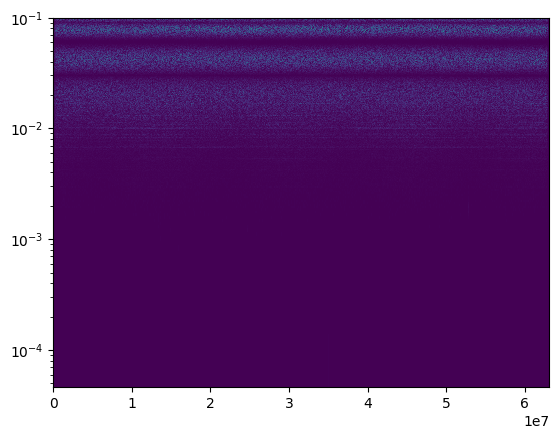

In [ ]:
# Build frequency edges from center frequencies
df = f_grid[1] - f_grid[0]
f_edges = np.r_[f_grid - 0.5 * df, f_grid[-1] + 0.5 * df]  # length nF+1

plt.pcolormesh(t_grid,f_edges,np.abs(mojito_sft_data[0,:,:]).T)
plt.semilogy()